In [18]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

# Warning off
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings("ignore")

In [38]:

df = pd.read_csv('/home/sunaybhat/results_PureDefense/From_Scratch/Narcissus/Results.csv')
df['Defense'] = df['Args'].apply(lambda x: json.loads(x)['baseline_defense'] if 'baseline_defense' in x else 'None')
df['Poison %'] = df['Args'].apply(lambda x: json.loads(x)['num_images_narcissus']/50000 if 'num_images_narcissus' in x else 0)
df.loc[df['Data Key'] != 'Baseline', 'Defense'] = df['Data Key'].apply(lambda x: x[0:3])


print('ResNet18 HLB CIFAR10 Narcissus Poison %\n_______________________________________')

for defense in df['Defense'].unique():

    for poison_pct in df['Poison %'].unique():
        df_defense = df[(df['Defense'] == defense) & (df['Poison %'] == poison_pct)]

        poison_success_mean = df_defense["P1 Acc"].mean()
        poison_success_std = df_defense["P1 Acc"].std()
        total_targets = len(df_defense["Target Index"].unique())
        end_acc = df_defense["End Acc"].mean()
        end_acc_std = df_defense["End Acc"].std()
        duplicate_targets = df_defense["Target Index"].value_counts()[df_defense["Target Index"].value_counts() > 1]

        print(f'Defense: {defense} | Poison %: {poison_pct:.2f} | Poison Success: {poison_success_mean:.2%}\u00B1{poison_success_std:.2f} | End Accuracy: {end_acc:.2%}\u00B1{end_acc_std:.2%} | Total Targets: {total_targets})')

        if not duplicate_targets.empty:
            print(f'Target indices with more than one value for {defense} {poison_pct}: {duplicate_targets}')


ResNet18 HLB CIFAR10 Narcissus Poison %
_______________________________________
Defense: None | Poison %: 0.01 | Poison Success: 37.48%±0.36 | End Accuracy: 93.49%±0.16% | Total Targets: 10)
Defense: None | Poison %: 0.02 | Poison Success: 53.02%±0.30 | End Accuracy: 93.68%±0.14% | Total Targets: 10)
Defense: None | Poison %: 0.05 | Poison Success: 72.54%±0.18 | End Accuracy: 93.27%±0.17% | Total Targets: 10)
Defense: None | Poison %: 0.10 | Poison Success: 94.97%±0.06 | End Accuracy: 84.55%±0.63% | Total Targets: 10)
Defense: EBM | Poison %: 0.01 | Poison Success: 1.42%±0.01 | End Accuracy: 91.44%±0.16% | Total Targets: 10)
Defense: EBM | Poison %: 0.02 | Poison Success: nan%±nan | End Accuracy: nan%±nan% | Total Targets: 0)
Defense: EBM | Poison %: 0.05 | Poison Success: nan%±nan | End Accuracy: nan%±nan% | Total Targets: 0)
Defense: EBM | Poison %: 0.10 | Poison Success: nan%±nan | End Accuracy: nan%±nan% | Total Targets: 0)


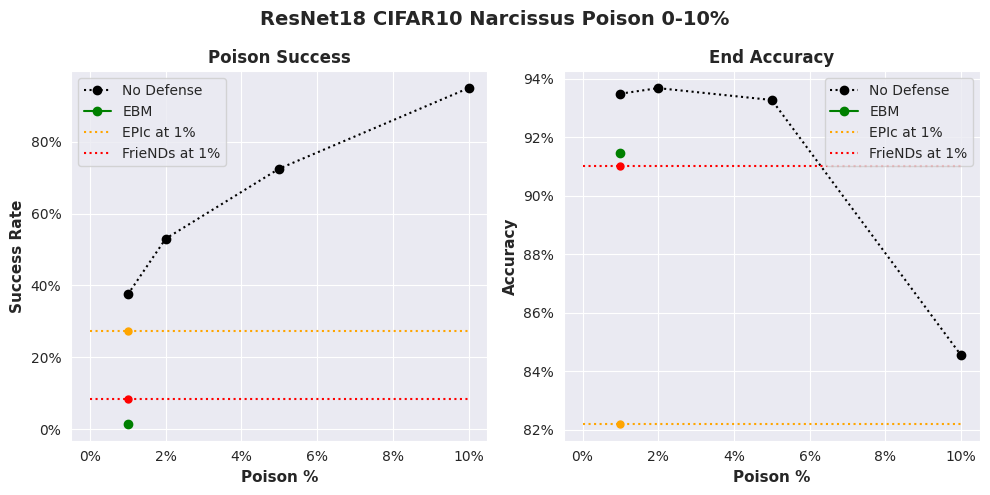

In [36]:
# Create 1x2 subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Define colors and styles for each defense
styles = {'None': {'color': 'black', 'linestyle': 'dotted', 'marker': 'o'},
          'EBM': {'color': 'green', 'linestyle': '-', 'marker': 'o'}}

# Loop over unique defenses
for defense in df['Defense'].unique():
    # Filter dataframe for the current defense
    df_defense = df[df['Defense'] == defense]
    
    # Calculate mean poison success and end accuracy for each poison %
    poison_success_means = df_defense.groupby('Poison %')["P1 Acc"].mean()
    end_acc_means = df_defense.groupby('Poison %')["End Acc"].mean()
    
    # Plot poison success and end accuracy
    axs[0].plot(poison_success_means.index, poison_success_means, **styles[defense],label=defense if defense != 'None' else 'No Defense')
    axs[1].plot(end_acc_means.index, end_acc_means, **styles[defense],label=defense if defense != 'None' else 'No Defense')

# EPic and FrieNDs at 1% Poison Success
axs[0].plot([0.01], [0.2732], marker='o', markersize=5, color="orange")
axs[0].hlines(0.2732, 0, 0.1, colors='orange', linestyles='dotted',label='EPIc at 1%')
axs[0].plot([0.01], [0.0832], marker='o', markersize=5, color="red")
axs[0].hlines(0.0832, 0, 0.1, colors='red', linestyles='dotted',label='FrieNDs at 1%')

# EPic and FrieNDs at 1% Poison Natural Accuracy
axs[1].plot([0.01], [0.822], marker='o', markersize=5, color="orange")
axs[1].hlines(0.822, 0, 0.1, colors='orange', linestyles='dotted',label='EPIc at 1%')
axs[1].plot([0.01], [0.9101], marker='o', markersize=5, color="red")
axs[1].hlines(0.9101, 0, 0.1, colors='red', linestyles='dotted',label='FrieNDs at 1%')

# Make x and y axis % format
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axs[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
axs[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Set plot titles, labels, and legends
axs[0].set_title('Poison Success',fontweight='bold',fontsize=12)
axs[0].set_xlabel('Poison %',fontweight='bold',fontsize=11)
axs[0].set_ylabel('Success Rate',fontweight='bold',fontsize=11)
axs[0].legend()

axs[1].set_title('End Accuracy',fontweight='bold',fontsize=12)
axs[1].set_xlabel('Poison %',fontweight='bold',fontsize=11)
axs[1].set_ylabel('Accuracy',fontweight='bold',fontsize=11)
axs[1].legend()

plt.suptitle('ResNet18 CIFAR10 Narcissus Poison 0-10%',fontweight='bold',fontsize=14)

plt.tight_layout()
